Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Columnas numéricas seleccionadas para el PCA: ['age', 'monthly_watch_time_mins', 'customer_support_tickets']


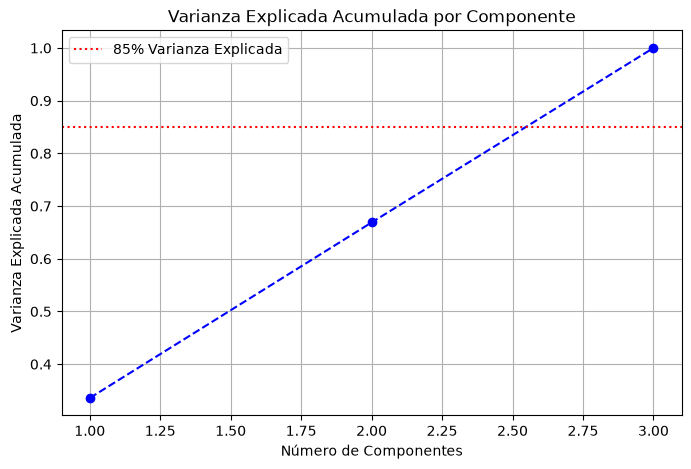


--- Pesos (Loadings) de las variables en cada Componente Principal ---
                            PC1    PC2    PC3
age                       0.691 -0.027  0.722
monthly_watch_time_mins   0.447  0.801 -0.398
customer_support_tickets  0.568 -0.598 -0.565


In [8]:
%pip install seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Cargar el dataset (ya sabemos que funciona)
df_eda = pd.read_csv("../data/processed/streaming_dataset_limpio.csv")

# 2. SELECCIÓN AUTOMÁTICA: Buscamos solo las columnas numéricas que tengan datos continuos
# (Excluimos columnas de ID si es que tenés alguna que sea numérica)
columnas_numericas = df_eda.select_dtypes(include=[np.number]).columns.tolist()

# Si hay alguna columna como 'id', 'user_id' o 'Unnamed: 0' que se coló, la sacamos:
columnas_a_excluir = ['id', 'user_id', 'Unnamed: 0']
columnas_numericas = [col for col in columnas_numericas if col not in columnas_a_excluir]

print("Columnas numéricas seleccionadas para el PCA:", columnas_numericas)

X = df_eda[columnas_numericas]

# 3. Estandarizar las variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Inicializar y aplicar PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 5. Calcular la varianza explicada acumulada
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

# 6. Graficar la Varianza Explicada Acumulada
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='--', color='b')
plt.title('Varianza Explicada Acumulada por Componente')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.axhline(y=0.85, color='r', linestyle=':', label='85% Varianza Explicada')
plt.legend()
plt.grid(True)
plt.show()

# 7. Mostrar los Loadings
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(len(columnas_numericas))], 
    index=columnas_numericas
)
print("\n--- Pesos (Loadings) de las variables en cada Componente Principal ---")
print(loadings.round(3))

El gráfico de varianza explicada acumulada revela que las dos primeras componentes principales (PC1 y PC2) logran capturar aproximadamente el 67% de la información total del dataset, lo que justifica reducir el análisis a estas dos dimensiones. Al observar la tabla de pesos (loadings), se evidencia que la PC1 representa el perfil de uso general, teniendo cargas positivas estables en la edad, los tickets y el tiempo de visualización. Por otro lado, la PC2 describe a un usuario maratonista e independiente, mostrando una fuerte relación positiva con los minutos mensuales de reproducción y una marcada carga negativa en los tickets de soporte.

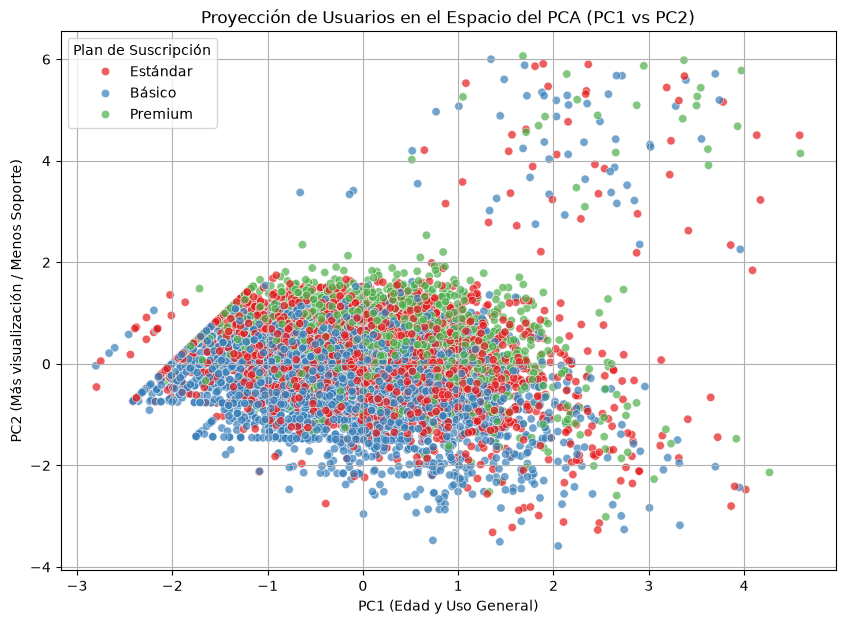

In [9]:
# Crear un nuevo DataFrame con las componentes principales y los datos originales
df_pca_plot = pd.DataFrame(data=X_pca[:, :2], columns=['PC1', 'PC2'])

# Le pegamos una variable categórica del dataset original para colorear (ej: 'subscription_plan')
# Cambiá 'subscription_plan' por la columna que vos tengas (ej: 'plan', 'country', etc.)
if 'subscription_plan' in df_eda.columns:
    df_pca_plot['plan'] = df_eda['subscription_plan'].values
    
    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=df_pca_plot, x='PC1', y='PC2', hue='plan', alpha=0.7, palette='Set1')
    plt.title('Proyección de Usuarios en el Espacio del PCA (PC1 vs PC2)')
    plt.xlabel('PC1 (Edad y Uso General)')
    plt.ylabel('PC2 (Más visualización / Menos Soporte)')
    plt.legend(title='Plan de Suscripción')
    plt.grid(True)
    plt.show()
else:
    # Si no encuentra esa columna categórica, te hace el scatter plot general
    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=df_pca_plot, x='PC1', y='PC2', alpha=0.5, color='purple')
    plt.title('Proyección de Usuarios en el Espacio del PCA')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.grid(True)
    plt.show()

La proyección bidimensional de los usuarios sobre el espacio de PCA revela una gran concentración de clientes promedio en la zona central e inferior izquierda de la nube de puntos. También, se observa un grupo secundario y más disperso que se dispara en la parte superior del eje PC2, lo que evidencia la existencia de usuarios ultra-maratonistas que consumen gran cantidad de contenido sin requerir atención técnica. Por último, los colores que representan a los planes Básico, Estándar y Premium se muestran completamente solapados en toda la distribución, lo que demuestra que el tipo de suscripción contratada no condiciona ni segmenta el comportamiento de uso o reclamos de los clientes.